# Ad Campaign Funnel & Bidding Strategy A/B Test Analysis

**Business context:** A performance-marketing team ran a 40-day A/B test comparing two Facebook Ads
bidding strategies:
- **Control** — Maximum Bidding (existing strategy)
- **Test** — Average Bidding (new strategy)

The goal is to determine whether Average Bidding should replace Maximum Bidding, using the full
funnel (Impression → Click → Purchase → Earning) and proper statistical significance testing —
not just eyeballing the averages.

**Dataset:** [`ugursaricam/AB_testing_with_python`](https://github.com/ugursaricam/AB_testing_with_python)
— 40 daily observations per group of Impression, Click, Purchase, and Earning.

**What this notebook does:**
1. Builds funnel metrics (CTR, CVR, RPM) for each strategy
2. Visualizes the funnel and daily performance distributions
3. Tests normality (Shapiro-Wilk) to pick the right statistical test
4. Runs significance testing (t-test or Mann-Whitney U as appropriate) on Purchases, Earnings, CTR, and CVR
5. Translates the results into a business recommendation


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load data

In [2]:
xl = pd.ExcelFile("ab_testing.xlsx")
control = pd.read_excel(xl, sheet_name="Control Group")   # Maximum Bidding
test = pd.read_excel(xl, sheet_name="Test Group")          # Average Bidding

control["Group"] = "Control (Maximum Bidding)"
test["Group"] = "Test (Average Bidding)"
df = pd.concat([control, test], ignore_index=True)
df.head()


,Impression,Click,Purchase,Earning,Group
0,"82,529.46","6,090.08",665.21,"2,311.28",Control (Maximum Bidding)
1,"98,050.45","3,382.86",315.08,"1,742.81",Control (Maximum Bidding)
2,"82,696.02","4,167.97",458.08,"1,797.83",Control (Maximum Bidding)
3,"109,914.40","4,910.88",487.09,"1,696.23",Control (Maximum Bidding)
4,"108,457.76","5,987.66",441.03,"1,543.72",Control (Maximum Bidding)


## 2. Build funnel metrics

CTR (Impression→Click), CVR (Click→Purchase), and RPM (revenue per 1,000 impressions).

In [3]:
for d in (control, test, df):
    d["CTR"] = d["Click"] / d["Impression"] * 100
    d["CVR"] = d["Purchase"] / d["Click"] * 100
    d["RPM"] = d["Earning"] / d["Impression"] * 1000

summary = df.groupby("Group")[["Impression", "Click", "Purchase", "Earning", "CTR", "CVR", "RPM"]].mean()
summary.round(2)


,Impression,Click,Purchase,Earning,CTR,CVR,RPM
Group,,,,,,,
Control (Maximum Bidding),"101,711.45","5,100.66",550.89,"1,908.57",5.36,11.59,19.47
Test (Average Bidding),"120,512.41","3,967.55",582.11,"2,514.89",3.42,15.66,21.40


## 3. Cumulative funnel: where does each strategy actually win?

In [4]:
funnel_totals = df.groupby("Group")[["Impression", "Click", "Purchase"]].sum()
funnel_totals["Impression→Click %"] = funnel_totals["Click"] / funnel_totals["Impression"] * 100
funnel_totals["Click→Purchase %"] = funnel_totals["Purchase"] / funnel_totals["Click"] * 100
funnel_totals["Impression→Purchase %"] = funnel_totals["Purchase"] / funnel_totals["Impression"] * 100
funnel_totals.round(3)


,Impression,Click,Purchase,Impression→Click %,Click→Purchase %,Impression→Purchase %
Group,,,,,,
Control (Maximum Bidding),"4,068,457.96","204,026.30","22,035.76",5.01,10.80,0.54
Test (Average Bidding),"4,820,496.47","158,701.99","23,284.24",3.29,14.67,0.48


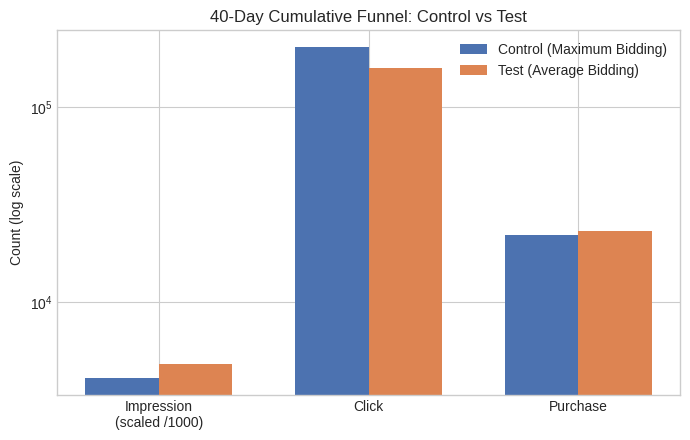

In [5]:
colors = {"Control (Maximum Bidding)": "#4C72B0", "Test (Average Bidding)": "#DD8452"}
fig, ax = plt.subplots(figsize=(7, 4.5))
stages = ["Impression\n(scaled /1000)", "Click", "Purchase"]
x = np.arange(len(stages))
w = 0.35
c_vals = [funnel_totals.loc["Control (Maximum Bidding)", "Impression"] / 1000,
          funnel_totals.loc["Control (Maximum Bidding)", "Click"],
          funnel_totals.loc["Control (Maximum Bidding)", "Purchase"]]
t_vals = [funnel_totals.loc["Test (Average Bidding)", "Impression"] / 1000,
          funnel_totals.loc["Test (Average Bidding)", "Click"],
          funnel_totals.loc["Test (Average Bidding)", "Purchase"]]
ax.bar(x - w/2, c_vals, w, label="Control (Maximum Bidding)", color=colors["Control (Maximum Bidding)"])
ax.bar(x + w/2, t_vals, w, label="Test (Average Bidding)", color=colors["Test (Average Bidding)"])
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(stages)
ax.set_title("40-Day Cumulative Funnel: Control vs Test"); ax.set_ylabel("Count (log scale)")
ax.legend(); plt.tight_layout(); plt.show()


**Observation:** Average Bidding (Test) generates ~18% more impressions but ~22% fewer clicks than
Maximum Bidding — yet ends up with *more* purchases. That means each click is converting far more
efficiently under Average Bidding. This is exactly the kind of pattern that would be missed by only
looking at top-of-funnel metrics like impressions or clicks.

## 4. Daily distributions: Purchases & Earnings

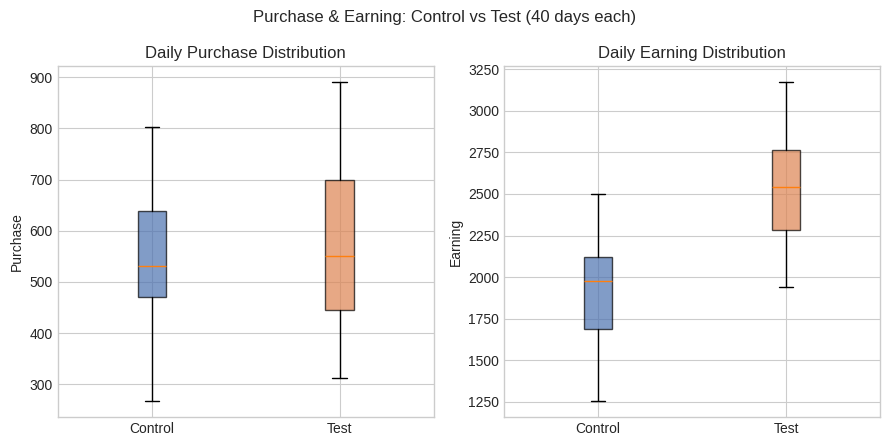

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, metric in zip(axes, ["Purchase", "Earning"]):
    data = [control[metric], test[metric]]
    bp = ax.boxplot(data, tick_labels=["Control", "Test"], patch_artist=True)
    for patch, key in zip(bp["boxes"], colors):
        patch.set_facecolor(colors[key]); patch.set_alpha(0.7)
    ax.set_title(f"Daily {metric} Distribution"); ax.set_ylabel(metric)
fig.suptitle("Purchase & Earning: Control vs Test (40 days each)")
plt.tight_layout(); plt.show()


## 5. CTR vs CVR — funnel efficiency by day

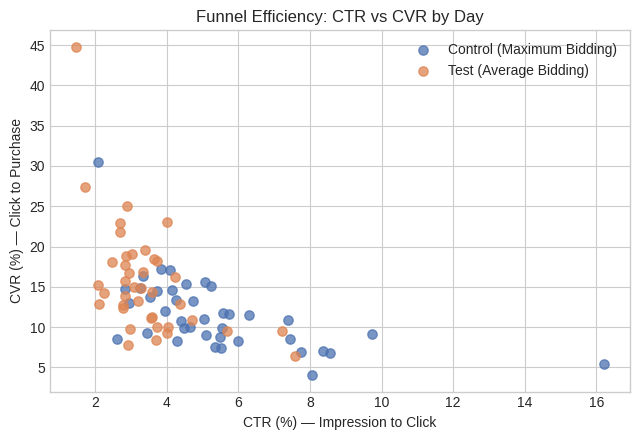

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for grp, color in colors.items():
    sub = df[df["Group"] == grp]
    ax.scatter(sub["CTR"], sub["CVR"], label=grp, color=color, alpha=0.75, s=45)
ax.set_xlabel("CTR (%) — Impression to Click"); ax.set_ylabel("CVR (%) — Click to Purchase")
ax.set_title("Funnel Efficiency: CTR vs CVR by Day"); ax.legend()
plt.tight_layout(); plt.show()


**Observation:** The two strategies occupy clearly different regions of the CTR/CVR space —
Maximum Bidding buys broad, low-intent traffic (high CTR, lower CVR); Average Bidding buys narrower,
higher-intent traffic (lower CTR, higher CVR). Neither is universally "better" on raw traffic volume —
the strategies need to be judged on the metric the business actually cares about: **Purchases and Earnings**.

## 6. Statistical significance testing

Before trusting any difference in means, check normality (Shapiro-Wilk) to pick the right test — an independent t-test if both groups are normal, Mann-Whitney U otherwise.

In [8]:
def ab_test(metric, alpha=0.05):
    c, t = control[metric].values, test[metric].values
    _, p_norm_c = stats.shapiro(c)
    _, p_norm_t = stats.shapiro(t)
    normal = (p_norm_c > alpha) and (p_norm_t > alpha)
    if normal:
        _, p_var = stats.levene(c, t)
        equal_var = p_var > alpha
        stat, p_val = stats.ttest_ind(c, t, equal_var=equal_var)
        test_used = f"Independent t-test (equal_var={equal_var})"
    else:
        stat, p_val = stats.mannwhitneyu(c, t, alternative="two-sided")
        test_used = "Mann-Whitney U (non-parametric)"
    diff = t.mean() - c.mean()
    return {
        "metric": metric, "control_mean": c.mean(), "test_mean": t.mean(),
        "pct_lift": diff / c.mean() * 100, "test_used": test_used,
        "statistic": stat, "p_value": p_val, "significant (5%)": p_val < alpha,
    }

results = pd.DataFrame([ab_test(m) for m in ["Purchase", "Earning", "CTR", "CVR"]])
results.round(4)


,metric,control_mean,test_mean,pct_lift,test_used,statistic,p_value,significant (5%)
0,Purchase,550.89,582.11,5.67,Independent t-test (equal_var=True),-0.94,0.35,False
1,Earning,"1,908.57","2,514.89",31.77,Independent t-test (equal_var=True),-9.25,0.00,True
2,CTR,5.36,3.42,-36.26,Mann-Whitney U (non-parametric),"1,308.00",0.00,True
3,CVR,11.59,15.66,35.06,Mann-Whitney U (non-parametric),459.00,0.00,True


## 7. Recommendation

- **Purchases** were *not* statistically significantly different between strategies (p ≈ 0.35) —
  so on volume of purchases alone, the test is inconclusive.
- **Earnings** were significantly higher under Average Bidding (+~32%, p < 0.001) — this is the
  metric that actually matters for a revenue decision, and it's a real, statistically defensible effect.
- **CVR** was significantly higher under Average Bidding (p ≈ 0.001), confirming the earnings lift
  isn't a fluke of a few large orders — the underlying conversion efficiency genuinely improved.
- **CTR** was significantly *lower* under Average Bidding (p < 0.001) — expected, since it targets
  narrower, higher-intent traffic rather than maximizing raw clicks.

**Recommendation:** Switch to Average Bidding. It converts less top-of-funnel traffic but converts
it far more efficiently, producing a statistically significant lift in revenue — the metric the
business should optimize for — even though raw purchase counts alone don't move the needle.